# CMU20 LLM Energy Comparison

This notebook loads the CMU20 energy test results of four LLM backends.

Figure saved: figure2_combined_panelabc.png


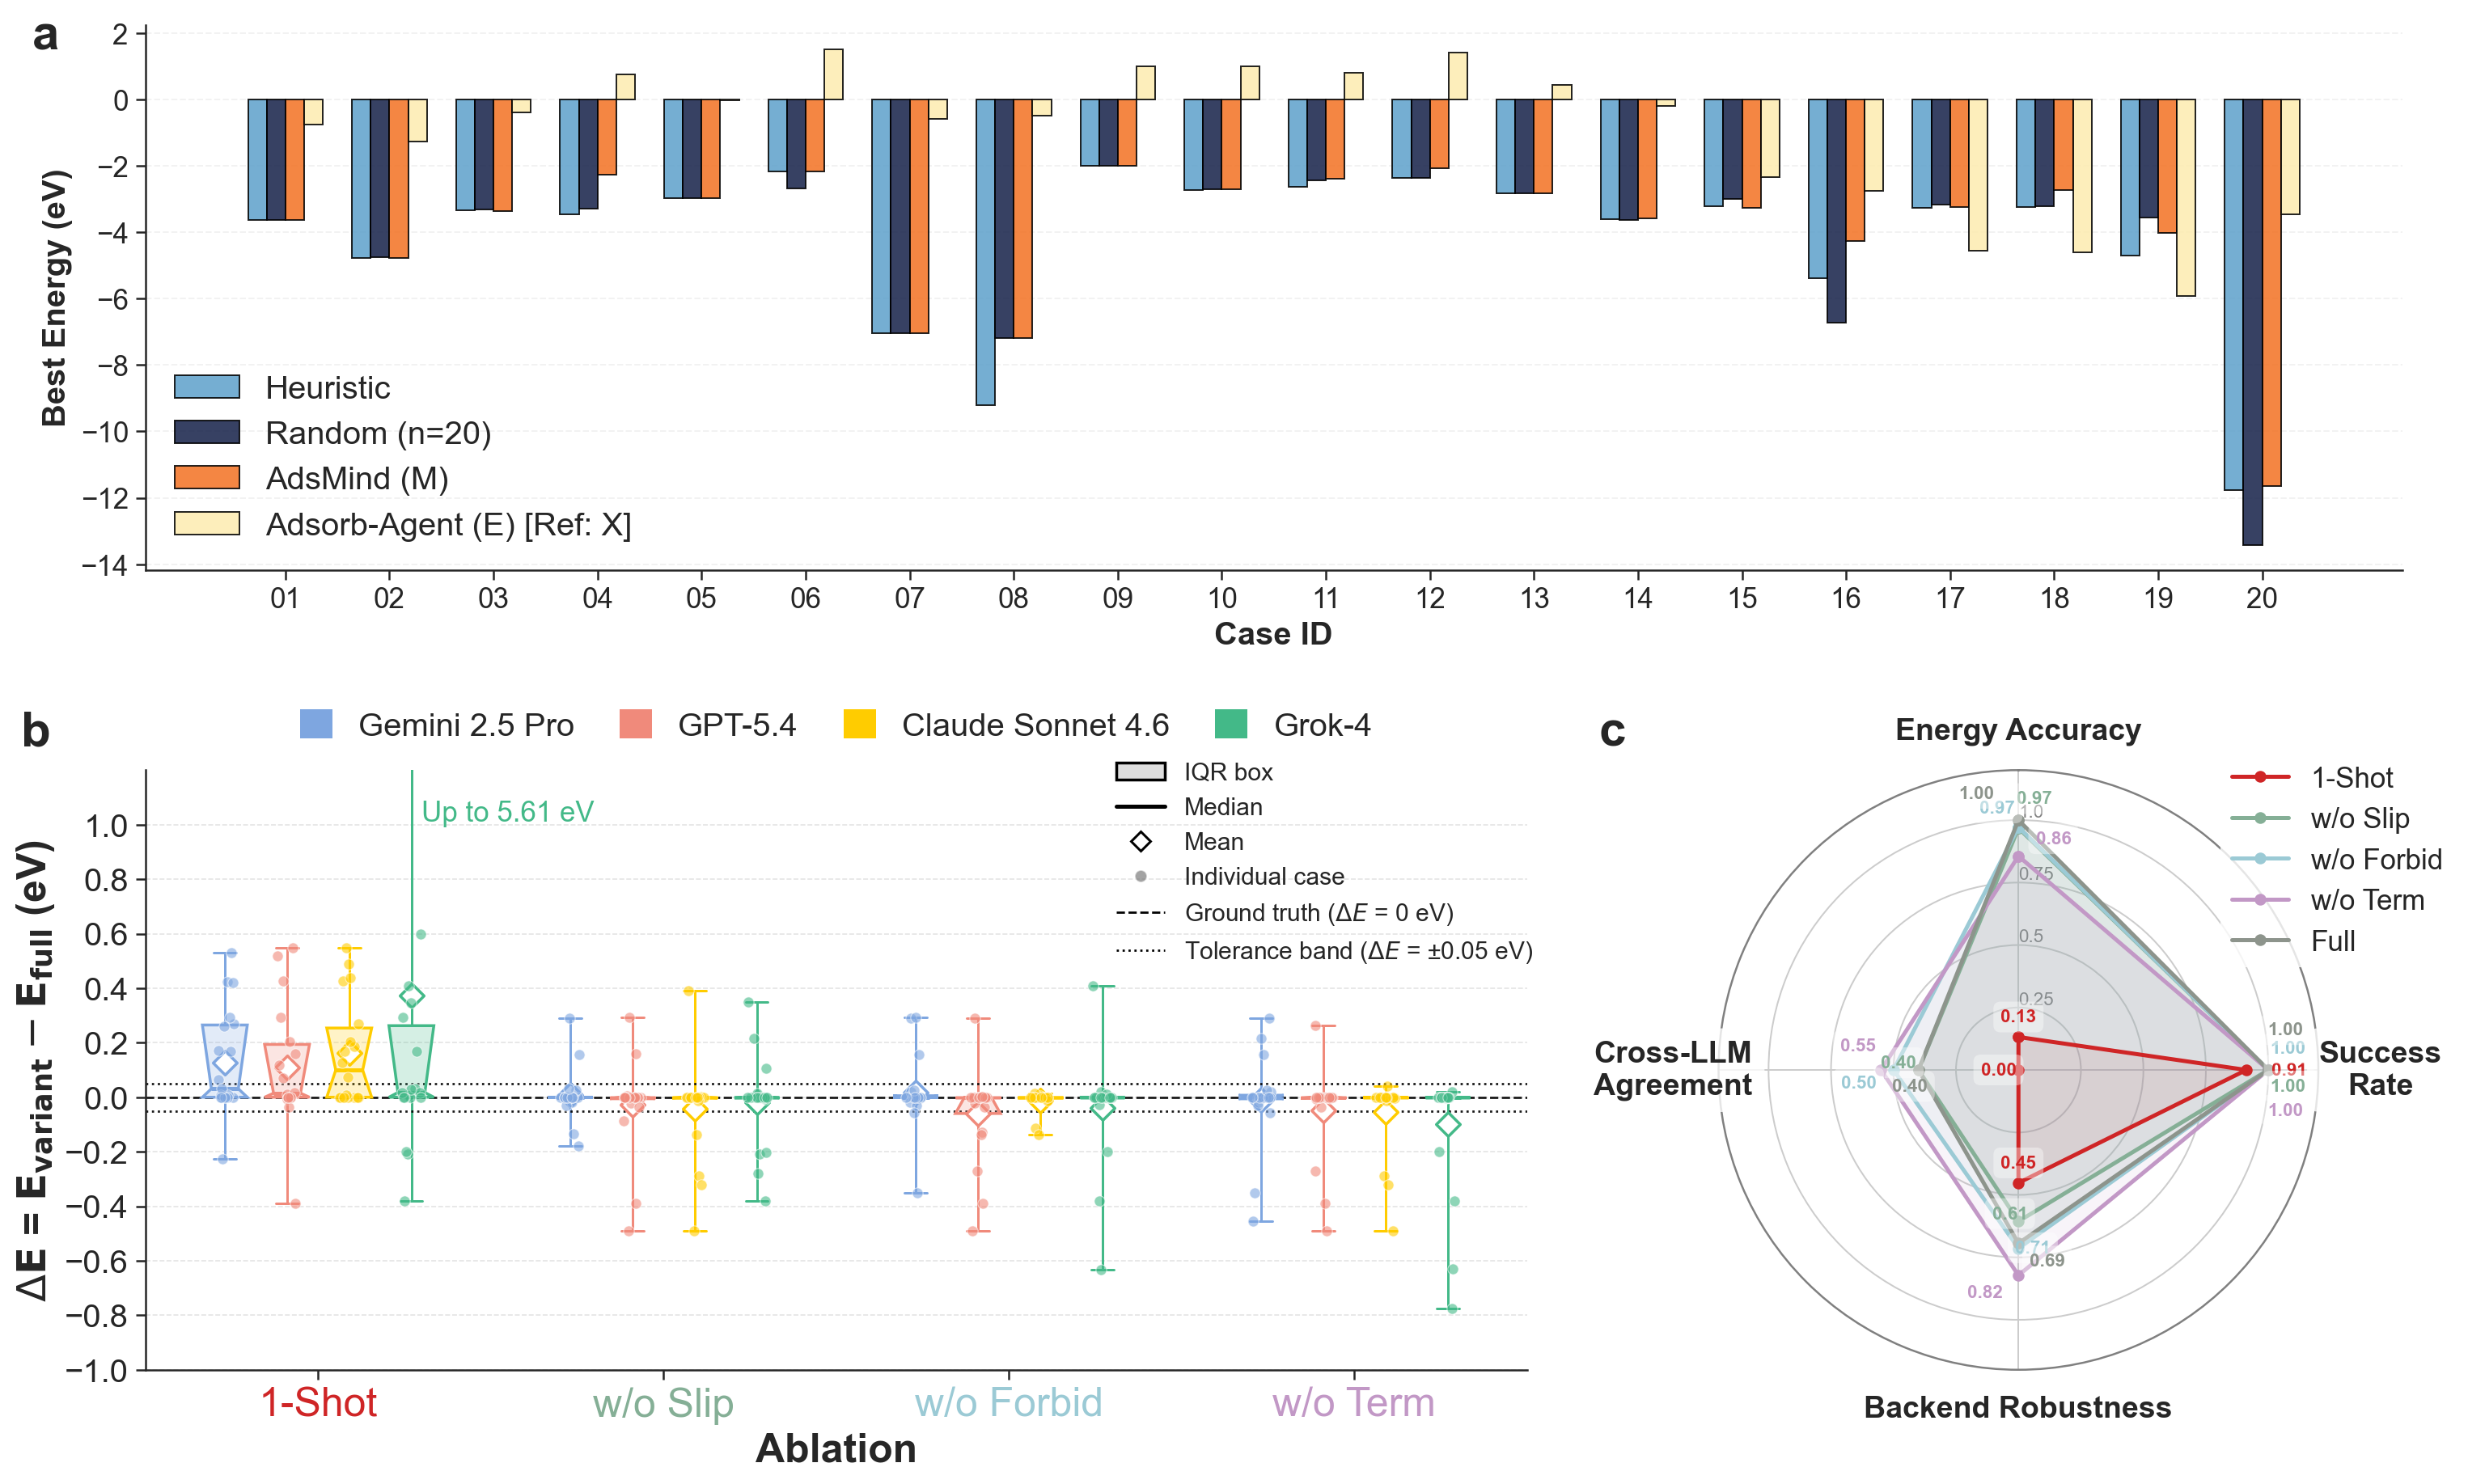

In [4]:
#!/usr/bin/env python
"""
Generate Figure 2 with three panels:
Panel a (top): SI Figure S1 strategy comparison
Panel b (bottom left): trapezoid plot (ablation performance across LLMs)
Panel c (bottom right): radar chart (variant comparison)
"""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="ticks", context="paper", font_scale=1.1)
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BASE = Path("../../..")

# ================================================================
# PANEL A: SI Figure S1 Strategy Comparison
# ================================================================
okabe = [ "#5DA0CB","#141F48", "#F37122", "#FDECAF"]

si_data = []

# AdsMind (GPT)
df = pd.read_csv(BASE / "research/results/processed/si_figures/basic_experiments/cmu20/gpt/full/summary.csv")
for _, r in df.iterrows():
    si_data.append({"case": int(r["case_id"]), "method": "AdsMind (M)", "energy": float(r["best_energy"])})

# Random (n=20)
df = pd.read_csv(BASE / "research/results/processed/si_figures/basic_experiments/cmu20/baselines/random_n20/summary.csv")
for _, r in df.iterrows():
    si_data.append({"case": int(r["case_id"]), "method": "Random (n=20)", "energy": float(r["best_energy"])})

# Heuristic
df = pd.read_csv(BASE / "research/results/processed/si_figures/basic_experiments/cmu20/baselines/heuristic/summary.csv")
for _, r in df.iterrows():
    si_data.append({"case": int(r["case_id"]), "method": "Heuristic", "energy": float(r["best_energy"])})

# Adsorb-Agent (run with mace_mp0_small)
'''
df = pd.read_csv(BASE / "research/results/processed/si_figures/basic_experiments/cmu20/baselines/adsorbagent_mace_mp0_small_gpt54/summary.csv")
for _, r in df.iterrows():
    if pd.notna(r["best_adsorption_energy_eV"]):
        si_data.append({"case": int(r["case_id"]), "method": "Adsorb-Agent (E)", "energy": float(r["best_adsorption_energy_eV"])})
'''

# Adsorb-Agent (paper values)
df = pd.read_csv(BASE / "research/paper_plots/scripts/CMU20_results_in_paper.csv")
for _, r in df.iterrows():
    if pd.notna(r["energy"]):
        si_data.append({"case": int(r["case_id"]), "method": "Adsorb-Agent (E) [Ref: X]", "energy": float(r["energy"])})

df_si1 = pd.DataFrame(si_data)
si_methods = df_si1.groupby("method")["energy"].mean().sort_values().index.tolist()

# ================================================================
# PANEL B/C: LLM ablation and radar
# ================================================================
adsmind_dir = Path("../../results/basic_experiments/cmu20/adsmind")
backend_dirs = ["gpt54_mace_mp0_small", "grok4_mace_mp0_small", "gemini25pro_mace_mp0_small", "claude_sonnet46_mace_mp0_small"]
frames = []
for b in backend_dirs:
    f = pd.read_csv(adsmind_dir / b / "all_variants_summary.csv")
    frames.append(f)
df_ablation = pd.concat(frames, ignore_index=True)
df_ablation = df_ablation.rename(columns={"best_energy": "best_energy_eV"})
df_ablation["case_id"] = df_ablation["case_id"].astype(str).str.strip().str.zfill(2)
df_ablation["best_energy_eV"] = pd.to_numeric(df_ablation["best_energy_eV"], errors="coerce")
df_ablation["success"] = df_ablation["success"].astype(str).str.upper().eq("TRUE")
df_ablation.loc[~df_ablation["success"], "best_energy_eV"] = np.nan

variant_map = {
    "full": "Full",
    "one_shot": "1-Shot",
    "no_slip": "-Slip",
    "no_forbid": "-Forbid",
    "no_termination": "-Term",
}
plot_order = ["1-Shot", "-Slip", "-Forbid", "-Term"]
backend_to_model = {
    "gemini": "Gemini 2.5 Pro",
    "gpt": "GPT-5.4",
    "claude": "Claude Sonnet 4.6",
    "grok": "Grok-4",
}

model_config = {
    "Gemini 2.5 Pro": {"color": "#7EA6E0"},
    "GPT-5.4":        {"color": "#F08A7B"},
    "Claude Sonnet 4.6": {"color": "#FFCC00"},
    "Grok-4":         {"color": "#43B988"},
}

frames = {}
for backend_key, model_name in backend_to_model.items():
    df_backend = df_ablation[df_ablation["backend_key"] == backend_key].copy()
    df_pivot = df_backend.pivot(index="case_id", columns="variant", values="best_energy_eV")
    df_pivot = df_pivot.rename(columns=variant_map)
    for col in ["Full"] + plot_order:
        if col not in df_pivot.columns:
            df_pivot[col] = np.nan
    df_pivot = df_pivot[["Full"] + plot_order]
    df_pivot = df_pivot.reset_index().rename(columns={"case_id": "Case"})
    for scenario in plot_order:
        df_pivot[scenario] = df_pivot[scenario] - df_pivot["Full"]
    df_pivot = df_pivot.sort_values("Case", key=lambda s: s.astype(int)).reset_index(drop=True)
    frames[model_name] = df_pivot

all_values = []
for model_name in model_config:
    for scenario in plot_order:
        all_values.extend(frames[model_name][scenario].dropna().to_numpy(dtype=float).tolist())
y_min = float(np.nanmin(all_values))
y_max = float(np.nanmax(all_values))
y_pad = 0.08 * max(1e-6, y_max - y_min)
y_lim = (y_min - y_pad, y_max + y_pad)

# Create 2x2 figure (top row spans both columns)
fig = plt.figure(figsize=(20, 12), dpi=180)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.1], width_ratios=[1.8, 1.0], hspace=0.35, wspace=0.1)
ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1], projection="polar")

# ---- Panel a: SI Figure S1 bar chart ----
cases = np.arange(1, 21)
n_m = len(si_methods)
bar_w = 0.18
for i, method in enumerate(si_methods):
    sub = df_si1[df_si1["method"] == method].sort_values("case")
    x = sub["case"].values.astype(float) + i * bar_w - n_m * bar_w / 2 + bar_w / 2
    ax_a.bar(x, sub["energy"], width=bar_w, label=method,
             color=okabe[i % 8], alpha=0.85, edgecolor="black")

ax_a.set_xlabel("Case ID", fontsize=16, fontweight="bold")
ax_a.set_ylabel("Best Energy (eV)", fontsize=16, fontweight="bold")
ax_a.set_xticks(cases)
ax_a.set_xticklabels([f"{i:02d}" for i in cases], fontsize=14)
ax_a.tick_params(axis="y", labelsize=14)
ax_a.legend(fontsize=16, loc="lower left", frameon=False)
ax_a.grid(True, alpha=0.25, linestyle="--", axis="y")
sns.despine(ax=ax_a)

# Panel label "a"
ax_a.text(-0.05, 1.02, "a", transform=ax_a.transAxes,
          fontsize=24, fontweight="bold", va="top", ha="left")

# ---- Panel b: trapezoid plot ----
rng = np.random.default_rng(2026)
model_names = list(model_config.keys())
n_models = len(model_names)
x_base = np.arange(1, len(plot_order) + 1)
offset_span = 0.54
offsets = np.linspace(-offset_span / 2.0, offset_span / 2.0, n_models)
box_half_width = 0.065
neck_half_width = 0.6 * box_half_width

for offset, model_name in zip(offsets, model_names):
    cfg = model_config[model_name]
    color = cfg["color"]
    df = frames[model_name]
    values_by_setting = [df[scenario].dropna().to_numpy(dtype=float) for scenario in plot_order]
    x_positions = x_base + offset

    ax_b.boxplot(
        values_by_setting, positions=x_positions, widths=2.0 * box_half_width,
        whis=(0, 100), patch_artist=True, showfliers=False,
        boxprops={"facecolor": "none", "edgecolor": "none", "linewidth": 0.0},
        whiskerprops={"color": color, "linewidth": 1.2},
        capprops={"color": color, "linewidth": 1.2},
        medianprops={"color": color, "linewidth": 0.0},
    )

    for pos, values in zip(x_positions, values_by_setting):
        if len(values) == 0:
            continue
        q1 = float(np.nanpercentile(values, 25))
        q3 = float(np.nanpercentile(values, 75))
        median_val = float(np.nanmedian(values))
        mean_val = float(np.nanmean(values))

        lower = Polygon([(pos - box_half_width, q1), (pos + box_half_width, q1),
                         (pos + neck_half_width, median_val), (pos - neck_half_width, median_val)],
                        closed=True, facecolor=to_rgba(color, 0.22), edgecolor=color, linewidth=1.4, zorder=3.1)
        upper = Polygon([(pos - neck_half_width, median_val), (pos + neck_half_width, median_val),
                         (pos + box_half_width, q3), (pos - box_half_width, q3)],
                        closed=True, facecolor=to_rgba(color, 0.22), edgecolor=color, linewidth=1.4, zorder=3.1)
        ax_b.add_patch(lower)
        ax_b.add_patch(upper)
        ax_b.hlines(median_val, pos - neck_half_width, pos + neck_half_width, color=color, linewidth=2.0, zorder=3.8)
        ax_b.scatter(pos, mean_val, marker="D", s=70, facecolor="white", edgecolor=color, linewidth=1.4, zorder=4)
        jitter = rng.uniform(-0.028, 0.028, size=len(values))
        ax_b.scatter(np.full_like(values, pos, dtype=float) + jitter, values,
                     s=28, color=color, edgecolors="white", linewidths=0.45, alpha=0.6, zorder=5)

ax_b.axhline(0.0, color="black", linestyle="--", linewidth=1.1, alpha=0.9, zorder=2)
ax_b.axhline(0.05, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)
ax_b.axhline(-0.05, color="black", linestyle=":", linewidth=1.1, alpha=0.9, zorder=2)

llm_handles = [Patch(facecolor=model_config[name]["color"], edgecolor="none", label=name)
               for name in model_names]
legend_llm = ax_b.legend(handles=llm_handles, loc="upper center", 
                         bbox_to_anchor=(0.5, 1.15),
                         ncol=n_models, frameon=False, handlelength=1.0, handleheight=1.0,
                         columnspacing=1.4, fontsize=16)
ax_b.add_artist(legend_llm)

style_handles = [
    Patch(facecolor=to_rgba("#666666", 0.22), edgecolor="black", linewidth=1.4, label="IQR box"),
    Line2D([0], [0], color="black", linewidth=2.0, label="Median"),
    Line2D([0], [0], marker="D", linestyle="None", markersize=7,
           markerfacecolor="white", markeredgecolor="black", markeredgewidth=1.2, label="Mean"),
    Line2D([0], [0], marker="o", linestyle="None", markersize=6,
           markerfacecolor="#666666", markeredgecolor="white", markeredgewidth=0.7,
           alpha=0.6, label="Individual case"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.1, label=r"Ground truth ($\Delta E$ = 0 eV)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.1, label=r"Tolerance band ($\Delta E$ = ±0.05 eV)"),
]
ax_b.legend(handles=style_handles, bbox_to_anchor=(1.02, 1.05), 
            loc="upper right", fontsize=12, frameon=False)
ax_b.set_xlim(0.5, len(plot_order) + 0.5)
ax_b.set_xticks(x_base)
ax_b.set_xticklabels(["1-Shot", "w/o Slip", "w/o Forbid", "w/o Term"])
ax_b.tick_params(axis="x", labelsize=20)
# Color x-axis labels to match Panel C legend
colors_xaxis = ["#CF2526", "#85AF96", "#9BCAD5", "#C298C6"]  # 1-Shot, w/o Slip, w/o Forbid, w/o Term
for tick, color in zip(ax_b.get_xticklabels(), colors_xaxis):
    tick.set_color(color)

ax_b.set_ylim(-1,1.2)
ax_b.set_yticks(np.arange(-1, 1.2, 0.2))
ax_b.text(0.2, 0.95, "Up to 5.61 eV", transform=ax_b.transAxes, 
          fontsize=14, color=model_config["Grok-4"]["color"], va="top", ha="left")

ax_b.tick_params(axis="y", labelsize=20)
ax_b.set_xlabel("Ablation", fontsize=20, fontweight="bold")
ax_b.set_ylabel(r"$\Delta \mathbf{E}$ = $\mathbf{E}_{\mathbf{variant}} - \mathbf{E}_{\mathbf{full}}$ (eV)", fontsize=20, fontweight="bold")
ax_b.tick_params(axis="y", labelsize=16)
ax_b.grid(True, axis="y", linestyle="--", linewidth=0.65, alpha=0.55)
ax_b.grid(False, axis="x")

# Panel label "b"
ax_b.text(-0.09, 1.1, "b", transform=ax_b.transAxes,
          fontsize=24, fontweight="bold", va="top", ha="left")

# ---- Panel c: Radar chart ----
table1_data = {
    "Variant": ["1-Shot", "w/o Slip", "w/o Forbid", "w/o Term", "Full"],
    "Mean_dE_vs_full_eV": [0.217, -0.008, -0.007, -0.036, 0.000],
    "Success_rate": [91.2, 100.0, 100.0, 100.0, 100.0],
}
table3_data = {
    "Variant": ["1-Shot", "w/o Slip", "w/o Forbid", "w/o Term", "Full"],
    "Mean_4backend_range_eV": [0.274, 0.197, 0.143, 0.089, 0.153],
    "Agreement_rate": [0.000000, 0.400000, 0.500000, 0.550000, 0.400000],
}
df1 = pd.DataFrame(table1_data)
df3 = pd.DataFrame(table3_data)
df_merged = pd.merge(df1, df3, on="Variant")
order = ["1-Shot", "w/o Slip", "w/o Forbid", "w/o Term", "Full"]
df_radar = df_merged.set_index("Variant").reindex(order).reset_index()

df_radar["Norm_dE"] = 1 - (np.abs(df_radar["Mean_dE_vs_full_eV"]) / 0.25)
df_radar["Norm_success"] = df_radar["Success_rate"] / 100
df_radar["Norm_robustness"] = 1 - (df_radar["Mean_4backend_range_eV"] / 0.5)
df_radar["Norm_agreement"] = df_radar["Agreement_rate"]
for col in ["Norm_dE", "Norm_success", "Norm_robustness", "Norm_agreement"]:
    df_radar[col] = df_radar[col].clip(0, 1)

colors_radar = ["#CF2526", "#85AF96", "#9BCAD5", "#C298C6", "#8D948C"]
categories = ["Energy Accuracy", "Success\nRate", "Backend Robustness", "Cross-LLM\nAgreement"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_c.set_theta_offset(np.pi / 2)
ax_c.set_theta_direction(-1)
ax_c.set_xticks(angles[:-1])
ax_c.set_xticklabels([])  # Clear auto labels; place manually below

# Manually place category labels with custom radial offsets
label_rs = [1.3, 1.45, 1.3, 1.7]
for i, (angle, label) in enumerate(zip(angles[:-1], categories)):
    r = label_rs[i]
    if i == 0:  # top
        va, ha = "bottom", "center"
    elif i == 1:  # left
        va, ha = "center", "center"
    elif i == 2:  # bottom
        va, ha = "top", "center"
    else:  # right (i == 3)
        va, ha = "center", "left"
    ax_c.text(angle, r, label, fontsize=15, fontdict={"weight": "bold"}, ha=ha, va=va,
              bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="none"))

ax_c.set_rlabel_position(0)
ax_c.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_c.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], color="grey", size=9)
ax_c.tick_params(axis="y", pad=12)
ax_c.set_ylim(0, 1.2)
ax_c.spines["polar"].set_edgecolor("grey")

# Manual label_r offsets: [variant_idx][metric_idx]
label_r_offsets = [
    [0.08, 0.17, -0.08, 0.08],  # 1-Shot
    [0.12, 0.08, -0.03, 0.08],  # w/o Slip
    [0.08, 0.08, 0.00, 0.14],  # w/o Forbid
    [0.08, 0.08, 0.08, 0.1],  # w/o Term
    [0.12, 0.08, 0.08, 0.04],  # Full
]
angle_offsets = [0, 0.06, -0.08, 0.15, -0.15]

for i, (idx, row) in enumerate(df_radar.iterrows()):
    values = df_radar.loc[idx, ["Norm_dE", "Norm_success", "Norm_robustness", "Norm_agreement"]].values.tolist()
    values += values[:1]
    ax_c.plot(angles, values, "o-", linewidth=2, label=row["Variant"], color=colors_radar[i])
    ax_c.fill(angles, values, alpha=0.1, color=colors_radar[i])
    for j, (angle, val) in enumerate(zip(angles[:-1], values[:-1])):
        label_r = val + label_r_offsets[i][j]
        text_angle = angle + angle_offsets[i]
        ax_c.text(text_angle, label_r, f"{val:.2f}",
                  ha="center", va="center",
                  fontsize=9, color=colors_radar[i], fontweight="bold",
                  bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.4, edgecolor="none"))

ax_c.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), fontsize=14, 
            facecolor="white", framealpha=0.8, frameon=True, edgecolor="none")

# Panel label "c"
ax_c.text(-0.2, 1.1, "c", transform=ax_c.transAxes,
          fontsize=24, fontweight="bold", va="top", ha="left")

# Save figure
fig.savefig("figure2_combined_panelabc.png", dpi=300, bbox_inches="tight")
print("Figure saved: figure2_combined_panelabc.png")
plt.show()